<a href="https://colab.research.google.com/github/Kohei-200/math/blob/main/not_important/38_83_conjecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Do the 38% rule and the 83% rule point to the same listening position, and does room mode simulation confirm or contradict them?

### **38% rule**
Initiates a good starting point at which the head of listener should be located.

<img src="https://drive.google.com/uc?export=view&id=1UL9UtmgKQqtrrZZrPIk26nrrJPQf373o" width="400">

[Home Studio Acoustics - Part 1
Optimal Positioning for Mixing Desk and Monitors](https://waveinformer.com/wp-content/uploads/2024/10/38percent.png)

Based on the assumption in a rectangular room shape with balanced absorption(reverbation) which are discussed later.

---

### **83% rule** (not to be tested)
<img src="https://drive.google.com/uc?export=view&id=1c_dKmLn222UlTDEtFCz97rJJOmsXMDRD" width="400">


Other empirical number, suggested by **Jim Smith**,
$$sin(∠XY) = \frac{X}{Y} = 0.83$$ tells the most likely smooth range in 25hz-250hz given $X$ between half of tweeters and $Y$ between a tweeter and a ear.
Therefore,
$$∠XY ≈ 56°$$
setting $D$ as the purple line, and
$$D = Ysin(56°) = Xtan(56°)$$
$$D ≈ 0.829Y ≈ 1.483X$$

This rule is used to fix the relationship between listening position and audio sources.


[The Magic Formula for Perfect Speaker Set-Up?! | W/ Jim Smith](https://www.youtube.com/watch?v=CX9y40bPkGI)

https://www.slashgear.com/2185461/what-is-83-percent-rule-for-speakers-overview/



To be Conputed:
- Empirical rules (38%, 83%) with geometry calculations
- 2D FDTD wave simulation with Gaussian source, two speakers, absorption
- Frequency response analysis via FFT
- Flatness sweep using Wiener entropy
- ~ x* from FDTD sweep (pending the argmin/argmax fix)

### Initialize the room setup

In [1]:
L = 8 # room length (Nx)
W = 4 # width (Ny)
W_speakers = 1.6 # distance between Speakers

calculate the empirical optimal setup

In [6]:
import math
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.stats import gmean
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

In [2]:
def Positions(L, # room length
              W_speakers # speakers distance
              ):
  '''
  return
  x_38: listener position
  speaker_38: speaker_center position

  '''
  x_38 = 0.38 * L # 38% listening depth

  W_83 = W_speakers / 2
  D_83 = math.tan(math.radians(56)) * W_83 # 83% listening depth
  speaker_x = x_38 - D_83
  return round(x_38, 3), round(speaker_x, 3)

x_38, speaker_38 = Positions(L, W_speakers)
x_38, speaker_38

(3.04, 1.854)

### FDTD

**2D Grids with finite difference time domain (FDTD)** which updates pressure $p$ at every (square)grid ($Δy = Δx$) point based on its neighbors.

<img src="https://drive.google.com/uc?export=view&id=1ShLrox53dcqA6e9x-3okXSRjBOnCLFwO" width="450">


The temporal acceleration of pressure $p$ at a time $t$ equals the speed of sound $c$ squared times the spatial curvature of pressure around it.
$$\frac{δ^2p}{δt^2} = c^2(\frac{δ^2p}{δx^2} + \frac{δ^2p}{δy^2})$$
Discretizing it gives:
$$\frac{δ^2p}{δx^2} ≈ \frac{p[i+1, j]-2p[i,j]+p[i, j-1]}{Δx^2}$$

$$\frac{δ^2p}{δt^2} ≈ \frac{p^{n+1}[i, j]-2p^n[i,j]+p^{n-1}[i,j]}{Δt^2}$$

---

given $Δy = Δx$ and set both $h$;
$$\frac{p^{n+1}[i, j] - 2p^n[i,j] + p^{n-1}[i,j]}{\Delta t^2} = c^2 (\frac{p[i+1, j] + p[i-1, j] + p[i, j+1] + p[i, j-1] - 4p[i,j]}{h^2})$$

---

This simulation use Stride = 0.05, Duration = 0.3.

The initial wall setting is **rigid** using Neumann condition, mirroring the pressure adjacent to the point.

Although predfined values [r_front=1.0, r_rear=1.0, r_side=1.0] can be modified with the
**reflection coefficient**$$\Gamma = \frac{Z_2 - Z_1}{Z_2 + Z_1}(\text{Impedance of air}:Z_1 = \rho_0c)$$ and corresponding
 **absorption coefficient** ($\alpha = 1 - \Gamma^2$), the frequencies are differently absorbed in reality, and are avoided to focus on other settings

---

To avoid placing an infinitely small listening point in a space, place 4 corner points on 30cm distance to shape a box and average the spacial data.

In [3]:
def simulate_wave(L, W,
                  spkr_depth,
                  lstnr_depth,
                  W_speakers,
                  stride, duration,
                  r_front=1.0, r_rear=1.0, r_side=1.0,
                  mode = "history"):
  '''
walls are rigid
sound ignores listener
the direction of sound is not explicitly calculated
  '''
  c = 343
  y_dev = int((W_speakers/2) / stride)

  y_grids = int(W/stride) + 1
  x_grids = int(L/stride) + 1
  center_y, center_x = y_grids // 2, x_grids // 2

  p_prev = np.zeros((y_grids, x_grids))
  p_now  = np.zeros((y_grids, x_grids))
  p_next = np.zeros((y_grids, x_grids))

  if not(0 <= spkr_depth <= L):
      raise ValueError(f"spkr_depth must be between 0 and {L}")
  else:
    spkr_r_y = center_y + y_dev
    spkr_l_y = center_y - y_dev
    spkr_x = int(spkr_depth / stride)

  dt = stride / (c * np.sqrt(2.0)) # CFL condition
  spatial_constant = (c**2 * dt**2) / (stride**2)
  num_steps = int(duration / dt)

  # Gaussian pulse (smoother than the static initialisation)
  # s(t) = exp(-(t-t0)^2 / 2sigma^2)
  t0 = 20 * dt        # delay before peak
  sigma = 5 * dt      # width of pulse

  history = []

  listener_distance = int(0.15 / stride)
  listeners = [[center_y + listener_distance, int(lstnr_depth / stride)],
              [center_y - listener_distance, int(lstnr_depth / stride)],
              [center_y , int(lstnr_depth / stride) + listener_distance],
              [center_y , int(lstnr_depth / stride) - listener_distance]]


  for t in range(num_steps):
      laplacian = (p_now[2:, 1:-1] +  # down
                   p_now[:-2, 1:-1] + # up
                   p_now[1:-1, 2:] +  # right
                   p_now[1:-1, :-2] - # left
                   4.0 * p_now[1:-1, 1:-1] # itself
                   )
      t_now = t * dt
      source = np.exp(-((t_now - t0)**2) / (2 * sigma**2))

      p_next[1:-1, 1:-1] = (2.0 * # update
                            p_now[1:-1, 1:-1] -
                            p_prev[1:-1, 1:-1] +
                            spatial_constant *
                            laplacian)

      p_next[spkr_r_y, spkr_x] += source
      p_next[spkr_l_y, spkr_x] += source


      p_next[:, 0]  *= r_front   # front wall
      p_next[:, -1] *= r_rear    # rear wall
      p_next[0, :]  *= r_side    # side wall
      p_next[-1, :] *= r_side    # side wall

      if mode == "history":
        if t % 10 == 0:
          history.append(p_now.copy())
      elif mode == "listener":
        temp_pressures = []
        for listener_y, listener_x in listeners:
          temp_pressures.append(p_now[listener_y, listener_x])
        history.append(np.mean(temp_pressures, axis = 0))

      # Swap pointers instead of copying
      p_prev, p_now, p_next = p_now, p_next, p_prev
  return history, dt

For selecting parameters, consider the maximum accurately simulated frequency:
$$f_{max} = \frac{c (= 343)}{10 × Δx}$$

In [4]:
h_source, dt = simulate_wave(8, 4,
                              spkr_depth=2.0,   # far from all walls
                              lstnr_depth=2.0,
                              W_speakers=1,
                              stride=0.005,
                              duration=0.01,
                              mode='listener')

Text(0.5, 1.0, 'Source pulse - time domain')

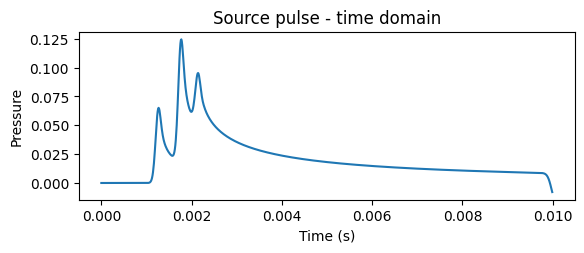

In [7]:
plt.subplot(2, 1, 1)
plt.plot(np.arange(len(h_source)) * dt, h_source)
plt.xlabel("Time (s)")
plt.ylabel("Pressure")
plt.title("Source pulse - time domain")

In [8]:
def frequency_response(listener_history, dt):
  N = len(listener_history)
  freqs = np.fft.fftfreq(N, d=dt)[:N//2]
  f = np.fft.fft(listener_history)[:N//2]
  A = np.abs(f)
  return freqs, A

Text(0.5, 1.0, 'Source pulse - frequency spectrum')

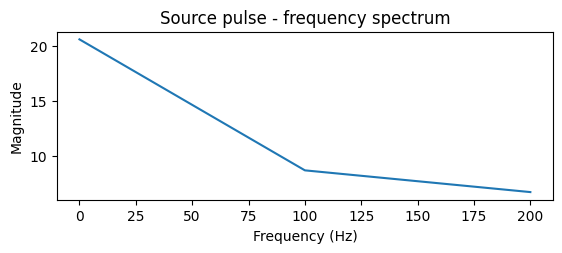

In [9]:
plt.subplot(2, 1, 2)
freqs, mag = frequency_response(h_source, dt)
mask = freqs <= 300
plt.plot(freqs[mask], mag[mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Source pulse - frequency spectrum")

### Animation

In [17]:
def animate(history, speakers, listeners, stride):
    fig, ax = plt.subplots()
    vmax = np.max(np.abs(history[0])) * 0.3
    im = ax.imshow(history[0], cmap="RdBu", vmin=-vmax, vmax=vmax)

    listener_y = [point[0] for point in listeners]
    listener_x = [point[1] for point in listeners]
    speaker_y = [point[0] for point in speakers]
    speaker_x = [point[1] for point in speakers]
    ax.scatter(listener_x, listener_y, color = "orange")
    ax.scatter(speaker_x, speaker_y, color = "black")

    def update(frame):
        data = history[frame]
        vmax = np.max(np.abs(data)) + 1e-10
        im.set_data(data)
        im.set_clim(-vmax, vmax)
        return [im]

    ani = FuncAnimation(fig, update, frames=len(history), interval=20)
    ani.save('wave_simulation.gif',
         writer='pillow',
         fps=15,
         dpi=80)
    return ani

In [18]:
x_38, speaker_pos = Positions(L, W_speakers)
stride = 0.05
speaker_pos_grid = int(speaker_pos/stride)
W_speakers_grid = int(W_speakers/stride)
center_w = int((W / 2) / stride)

spkr_x = int(speaker_pos / stride)
y_dev  = int((W_speakers/2) / stride)
center_y = int(W/stride) // 2

listener_distance = int(0.15 / stride)
x_38_grid = int(x_38 / stride)

speakers = [
    [center_y + y_dev, speaker_pos_grid],
    [center_y - y_dev, speaker_pos_grid]
]

listeners = [[center_w  + listener_distance, x_38_grid],
            [center_w - listener_distance, x_38_grid],
            [center_w, x_38_grid  + listener_distance,],
            [center_w, x_38_grid  - listener_distance,]]

In [ ]:
h, dt = simulate_wave(L, W, spkr_depth=speaker_pos, lstnr_depth=x_38,
                  W_speakers=W_speakers, stride=0.05, duration=0.3, mode="history")
HTML(animate(h, speakers, listeners, stride).to_jshtml())

![wave simulation](wave_simulation.gif)

### Validating on 38% rule's performance on other room setups

In [13]:
def flatness_score(mag): # Wiener Entropy
    mag = mag + 1e-10  # avoid log(0)
    return gmean(mag) / np.mean(mag)

In [14]:
rooms = [
    {"L": 8,  "W": 4},
    {"L": 4,  "W": 4},
    {"L": 6,  "W": 4},
    {"L": 7,  "W": 4.5},
    {"L": 10, "W": 5},
]
results = []

for room in rooms:
    L, W = room["L"], room["W"]
    x_38, speaker_pos = Positions(L, W_speakers)
    positions = np.linspace(speaker_pos, 0.9*L, 100)
    flatness = []

    for pos in positions:
        h, dt = simulate_wave(L, W, spkr_depth=speaker_pos,
                              lstnr_depth=pos,
                              W_speakers=W_speakers,
                              stride=0.05, duration=0.3,
                              mode="listener")
        freqs, mag = frequency_response(h, dt)
        mask = freqs <= 300
        flatness.append(flatness_score(mag[mask]))
    max_score = np.max(flatness)

    h, dt = simulate_wave(L, W, spkr_depth=speaker_pos,
                          lstnr_depth=x_38,
                          W_speakers=W_speakers,
                          stride=0.05, duration=0.3,
                          mode="listener")
    freqs, mag = frequency_response(h, dt)
    mask = freqs <= 300
    flatness_38 = flatness_score(mag[mask])

    flatness_smooth = uniform_filter1d(flatness, size=3)
    x_star = positions[np.argmax(flatness_smooth)]

    results.append({
            "room": f"{L}×{W}",
            "x_38": round(x_38, 2),
            "flatness loss": round((max_score - flatness_38), 2),
            "error(%)": round((max_score - flatness_38)/max_score * 100, 2)
        })

for r in results:
    print(r)

{'room': '8×4', 'x_38': 3.04, 'flatness loss': np.float64(0.07), 'error(%)': np.float64(11.11)}
{'room': '4×4', 'x_38': 1.52, 'flatness loss': np.float64(0.09), 'error(%)': np.float64(14.67)}
{'room': '6×4', 'x_38': 2.28, 'flatness loss': np.float64(0.01), 'error(%)': np.float64(1.51)}
{'room': '7×4.5', 'x_38': 2.66, 'flatness loss': np.float64(0.0), 'error(%)': np.float64(0.72)}
{'room': '10×5', 'x_38': 3.8, 'flatness loss': np.float64(0.05), 'error(%)': np.float64(7.08)}


over on 5 settings, 38% rule have predicted the "sweet spot" with errors ranging from 0.72% on 7 x 4.5 setup to 14.67% on 4 x 4 square room.

Interestingly, the 38% rule predicts well on a room with a Width-Length ratio closer to the golden ratio(~ 1.6). More simulation needs to be done to find this.

### 38% vs x* frequency responses

take 38% rule and compare with the result of peaking (conversely, the flatness), and against the simulated optimal position of listener $x*$.

In [15]:
def find_x_star(L, W_speakers):
    _, speaker_pos = Positions(L, W_speakers)
    positions = np.linspace(speaker_pos, 0.9*L, 100) # ranging in front of audio source
    flatness = []

    for pos in positions:
        h, dt = simulate_wave(L, W, spkr_depth=speaker_pos,
                          lstnr_depth=pos,
                          W_speakers=W_speakers,
                          stride=0.05,
                          duration=0.3,
                          mode="listener")
        freqs, mag = frequency_response(h, dt)
        mask = freqs <= 300
        flatness.append(flatness_score(mag[mask]))

    best_idx = np.argmax(flatness)
    return positions[best_idx], positions, flatness


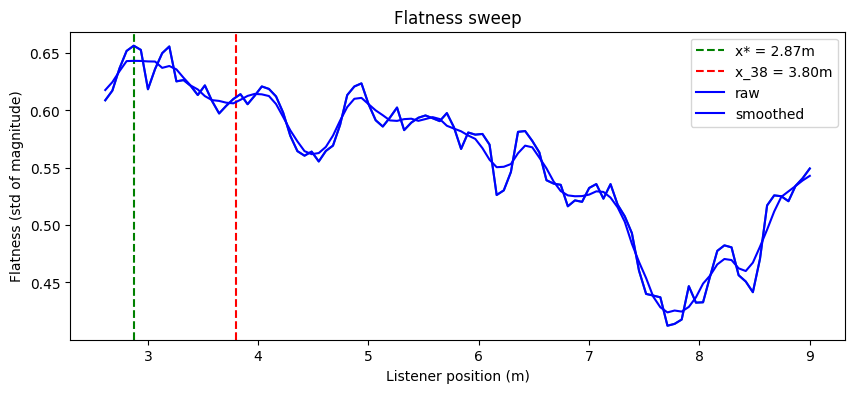

In [16]:
x_star_fdtd, positions, flatness = find_x_star(L, W_speakers)
plt.figure(figsize=(10, 4))
plt.plot(positions, flatness)
plt.axvline(x=x_star_fdtd, color="g", linestyle="--", label=f"x* = {x_star_fdtd:.2f}m")
plt.axvline(x=0.38*L, color="r", linestyle="--", label=f"x_38 = {0.38*L:.2f}m")
plt.xlabel("Listener position (m)")
plt.ylabel("Flatness (std of magnitude)")
plt.title("Flatness sweep")

flatness_smooth = uniform_filter1d(flatness, size=5)
x_star_fdtd = positions[np.argmin(flatness_smooth)]
plt.plot(positions, flatness, color="blue", label="raw")
plt.plot(positions, flatness_smooth, color="blue", label="smoothed")
plt.legend()
plt.show()

The flatness sweep plot shows that empirical 38% positioning of a listener is slightly off in this single setup.


However, the result on both flatness score and x* is somewhat sceptical because of the simulation quality. Mainly because:

- The omnidirectional pulsing radiates sound equally in all directions which is unpractical for simulating a face-to-face relationship between listeners and tweeters.
- Grid spacing stride=0.05m introduces a small frequency error

<a id = 's5'></a>
### 5. Conclude

38% rule performs well (error <2%) when $L/W ≈ 1.5$, and degrades as the room approaches square proportions.
This suggests the rule implicitly assumes a well-proportioned rectangular room.



Following simulation needs to be done to stablize x* on a more realistic settings, such as;
- the direction of a speaker (Tweeters/Woofers)
- hence the absorption bihavior on different frequencies
- objects that absorb/reflect the wave

One cycle of simulating wave takes about a minute on CPU, and moving on to 3D simulation with height sounds nice too.

Many variables were defined redundantly, and turning this into class object is prefered from next time.